In [1]:
"""
ШЧ-2: очистка, временные ряды, кластеризация, корреляции, SPC (Шухарт/EWMA/CUSUM).

Зависимости:
    pip install polars openpyxl scikit-learn scipy matplotlib numpy

Запуск:
    python shch2_pipeline.py --input "ШЧ_2_corr.xlsx" --outdir out
"""

from __future__ import annotations

import argparse
import math
import warnings
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy import stats
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import openpyxl
warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(30)


polars.config.Config

In [2]:
# ----------------------------------------------------------------------
# Константы: имена колонок исходного файла
# ----------------------------------------------------------------------------
C_DATE      = "Дата осмотра"
C_INSPECTOR = "Осмотр проводил"
C_STATION   = "Станция, перегон"
C_OBJ       = "Объекты, количество отступлений"
C_GROUP     = "Классификация (Группа)"
C_KIND      = "Классификация (Вид)"
C_NOTE      = "Примечание"
C_DEADLINE  = "Крайний срок"
C_STATUS    = "Статус"
C_REASON    = "Причина"
C_FIXED     = "Дата устранения"

TEST_TOKENS = {"тест", "test", "-", "dddd", "ккквак", "ттт", "."}

# 1. ЗАГРУЗКА
def load_all_sheets(path) -> pl.DataFrame:
    """Читает все листы Excel и склеивает в один DataFrame с колонкой sheet."""   

    wb = openpyxl.load_workbook(path, read_only=True) # через библиотеку получаем список всех листов
    sheets = wb.sheetnames # список наших листов
    wb.close() # завершанием чтение файла 

    frames = [] #обзявляем пустов список, в который будем записывать считанные листы
    for sh in sheets: # в цикле считываем данные с листов c попыткой считать и выводом информации об ошике, если не сложилось
        try: 
            d = pl.read_excel(path, sheet_name=sh)
        except Exception as e:  # noqa: BLE001
            print(f"  [!] лист '{sh}' не прочитан: {e}")
            continue
        if d.height == 0:
            continue
        # унифицируем: всё в строки, чтобы vstack не падал на разных типах
        d = d.select([pl.col(c).cast(pl.Utf8, strict=False) for c in d.columns])
        d = d.with_columns(pl.lit(sh).alias("sheet"))
        frames.append(d) #пополянем ранее сформированный список 
        print(f"  лист '{sh}': {d.height} строк, {d.width} колонок")

    if not frames:
        raise RuntimeError("Не удалось прочитать ни один лист")

    # выравниваем набор колонок
    all_cols = []
    for f in frames:
        for c in f.columns:
            if c not in all_cols:
                all_cols.append(c)
    frames = [
        f.with_columns([pl.lit(None, dtype=pl.Utf8).alias(c)
                        for c in all_cols if c not in f.columns]).select(all_cols)
        for f in frames
    ]
    df = pl.concat(frames, how="vertical") #объединияем все данные из списка датафреймов в один массив 
    # print(f"  ИТОГО: {df.height} строк")
    return df

Path = 'ШЧ_2_corr.xlsx'
df = load_all_sheets(Path)
df[:3]

Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 10, falling back to string


  лист '2019': 12112 строк, 13 колонок
  лист '2018': 11110 строк, 13 колонок


Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 10, falling back to string


  лист '2017': 12052 строк, 13 колонок
  лист '2016': 2602 строк, 13 колонок
  лист '2015': 4684 строк, 13 колонок
  лист '2014': 3431 строк, 13 колонок


__UNNAMED__0,Дата осмотра,Осмотр проводил,"Станция, перегон","Объекты, количество отступлений",Классификация (Группа),Классификация (Вид),Примечание,Крайний срок,Статус,Причина,Дата устранения,sheet
str,str,str,str,str,str,str,str,str,str,str,str,str
"""0""","""2019-04-03""","""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""Стрелка №39 устранить люфт дли…","""2019-04-13""","""ЗАКРЫТО""",null,"""2019-04-11""","""2019"""
"""1""","""2019-04-03""","""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""Стрелка №25 отрегулировать раб…","""2019-04-13""","""ЗАКРЫТО""",null,"""2019-04-11""","""2019"""
"""2""","""2019-04-03""","""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""Стрелка №31 устранить люфт дли…","""2019-04-13""","""ЗАКРЫТО""",null,"""2019-04-11""","""2019"""


In [3]:
df['sheet'].value_counts()

sheet,count
str,u32
"""2016""",2602
"""2019""",12112
"""2017""",12052
"""2015""",4684
"""2018""",11110
"""2014""",3431


In [4]:
# 2. ОЧИСТКА
def parse_date_col(name: str, alias: str) -> pl.Expr:
    """Робастный парсинг даты: пробуем несколько форматов."""
    c = pl.col(name).cast(pl.Utf8, strict=False).str.strip_chars()
    return (
        pl.coalesce([
            c.str.to_datetime("%Y-%m-%d %H:%M:%S", strict=False),
            c.str.to_datetime("%Y-%m-%d", strict=False),
            c.str.to_datetime("%d.%m.%Y", strict=False),
        ])
        .dt.date()
        .alias(alias)
    )


def clean(df: pl.DataFrame) -> tuple[pl.DataFrame, pl.DataFrame]:
    """
    Возвращает (clean_df, report_df).
    Ничего не удаляет молча: проблемные строки помечаются флагами.
    """
    log: list[dict] = []

    def note(step: str, value):
        log.append({"step": step, "value": str(value)})

    n0 = df.height
    note("исходных строк", n0)

    # --- 2.1 нормализация текста ---
    text_cols = [c for c in (C_INSPECTOR, C_STATION, C_GROUP, C_KIND,
                             C_STATUS, C_NOTE, C_REASON) if c in df.columns]
    df = df.with_columns([
        pl.col(c).cast(pl.Utf8, strict=False)
          .str.replace_all(r"[\r\n]+", " ")
          .str.replace_all(r"\s+", " ")
          .str.strip_chars()
          .alias(c)
        for c in text_cols
    ])
    df = df.with_columns([
        pl.when(pl.col(c).str.len_chars() == 0).then(None).otherwise(pl.col(c)).alias(c)
        for c in text_cols
    ])

    # --- 2.2 даты ---
    df = df.with_columns([
        parse_date_col(C_DATE,     "d_insp"),
        parse_date_col(C_DEADLINE, "d_dead"),
        parse_date_col(C_FIXED,    "d_fix"),
    ])
    note("null d_insp после парсинга", df["d_insp"].null_count())
    note("null d_dead после парсинга", df["d_dead"].null_count())
    note("null d_fix  после парсинга", df["d_fix"].null_count())

    # --- 2.3 расщепление смешанной колонки «Объекты, количество отступлений» ---
    if C_OBJ in df.columns:
        raw = pl.col(C_OBJ).cast(pl.Utf8, strict=False).str.strip_chars()
        df = df.with_columns([
            raw.str.extract(r"^(\d+)$", 1).cast(pl.Int64, strict=False).alias("obj_count"),
            raw.alias("obj_raw"),
        ])
        df = df.with_columns(
            pl.when(pl.col("obj_count").is_null())
              .then(pl.col("obj_raw"))
              .otherwise(None)
              .alias("obj_label")
        )
        note("числовых obj_count", df["obj_count"].is_not_null().sum())
        note("текстовых obj_label", df["obj_label"].is_not_null().sum())

    # --- 2.4 статусы ---
    if C_STATUS in df.columns:
        df = df.with_columns(
            pl.col(C_STATUS).str.to_uppercase().alias("status_norm")
        )
        note("уникальных статусов", df["status_norm"].unique().to_list())

    # --- 2.5 производные признаки-интервалы ---
    df = df.with_columns([
        (pl.col("d_dead") - pl.col("d_insp")).dt.total_days().alias("norm_days"),
        (pl.col("d_fix")  - pl.col("d_insp")).dt.total_days().alias("lead_days"),
        (pl.col("d_fix")  - pl.col("d_dead")).dt.total_days().alias("overdue_days"),
    ])

    # --- 2.6 флаги качества ---
    is_test = pl.col(C_NOTE).str.to_lowercase().is_in(list(TEST_TOKENS))
    df = df.with_columns([
        pl.col("d_insp").is_null().alias("flag_no_insp_date"),
        (pl.col("lead_days") < 0).fill_null(False).alias("flag_fix_before_insp"),
        (pl.col("norm_days") < 0).fill_null(False).alias("flag_dead_before_insp"),
        (pl.col("lead_days") > 365 * 3).fill_null(False).alias("flag_lead_gt_3y"),
        is_test.fill_null(False).alias("flag_test_note"),
        ((pl.col("status_norm") != "НОВОЕ") & pl.col("d_fix").is_null())
            .fill_null(False).alias("flag_closed_no_fixdate"),
        (pl.col("d_fix") == pl.date(2019, 1, 26)).fill_null(False)
            .alias("flag_mass_close_20190126"),
    ])
    for f in [c for c in df.columns if c.startswith("flag_")]:
        note(f, df[f].sum())

    # --- 2.7 дубликаты ---
    note("полных дублей", df.is_duplicated().sum())
    bkey = [c for c in ("d_insp", C_STATION, "obj_raw", C_GROUP, C_KIND)
            if c in df.columns]
    n_before = df.height
    df = df.unique(subset=bkey, keep="first", maintain_order=True)
    note("удалено дублей по бизнес-ключу", n_before - df.height)

    # --- 2.8 выбросы lead_days: robust z / IQR ---
    ld = df.filter(pl.col("lead_days").is_not_null())["lead_days"].to_numpy()
    if ld.size > 10:
        q1, q3 = np.percentile(ld, [25, 75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        med = np.median(ld)
        mad = np.median(np.abs(ld - med)) or 1.0
        note("lead_days IQR-границы", (round(lo, 1), round(hi, 1)))
        note("lead_days вне IQR", int(((ld < lo) | (ld > hi)).sum()))
        df = df.with_columns([
            ((pl.col("lead_days") < lo) | (pl.col("lead_days") > hi))
                .fill_null(False).alias("flag_lead_outlier_iqr"),
            (0.6745 * (pl.col("lead_days") - med) / mad).abs()
                .alias("lead_robust_z"),
        ])
        # winsorize для моделирования (исходное значение сохраняется)
        df = df.with_columns(
            pl.col("lead_days").clip(0, max(hi, 1)).alias("lead_days_w")
        )

    # --- 2.9 «валидное ядро» для анализа ---
    df = df.with_columns(
        (~pl.col("flag_no_insp_date")
         & ~pl.col("flag_test_note")
         & ~pl.col("flag_fix_before_insp")).alias("is_valid")
    )
    note("валидных строк (is_valid)", df["is_valid"].sum())

    return df, pl.DataFrame(log)


# ============================================================================
# 3. ВРЕМЕННЫЕ РЯДЫ
# ============================================
def calendar_features(df: pl.DataFrame, date_col: str = "d_insp") -> pl.DataFrame:
    """Календарные признаки + циклическое кодирование."""
    d = pl.col(date_col)
    return df.with_columns([
        d.dt.year().alias("year"),
        d.dt.quarter().alias("quarter"),
        d.dt.month().alias("month"),
        d.dt.week().alias("iso_week"),
        d.dt.day().alias("day"),
        d.dt.weekday().alias("weekday"),
        d.dt.ordinal_day().alias("doy"),
        (d.dt.weekday() >= 6).alias("is_weekend"),
        d.dt.month_start().alias("month_start"),
        # циклические
        (2 * math.pi * d.dt.month() / 12).sin().alias("month_sin"),
        (2 * math.pi * d.dt.month() / 12).cos().alias("month_cos"),
        (2 * math.pi * d.dt.weekday() / 7).sin().alias("dow_sin"),
        (2 * math.pi * d.dt.weekday() / 7).cos().alias("dow_cos"),
    ])


def build_series(df: pl.DataFrame, every: str, date_col: str = "d_insp") -> pl.DataFrame:
    """
    Строит регулярный временной ряд с заданной дискретностью.
    every: '1d' | '1w' | '1mo' | '1q' | '1y'
    """
    base = (
        df.filter(pl.col("is_valid"))
          .select([
              pl.col(date_col).dt.truncate(every).alias("t"),
              pl.col(C_STATION).alias("station"),
              pl.col(C_INSPECTOR).alias("inspector"),
              pl.col(C_GROUP).alias("grp"),
              pl.col("obj_count"),
              pl.col("lead_days_w"),
              pl.col("overdue_days"),
          ])
          .group_by("t")
          .agg([
              pl.len().alias("n"),
              pl.col("station").n_unique().alias("n_stations"),
              pl.col("inspector").n_unique().alias("n_inspectors"),
              pl.col("grp").n_unique().alias("n_groups"),
              pl.col("obj_count").sum().alias("obj_sum"),
              pl.col("lead_days_w").mean().alias("lead_mean"),
              pl.col("lead_days_w").median().alias("lead_median"),
              (pl.col("overdue_days") > 0).mean().alias("overdue_rate"),
          ])
          .sort("t")
    )
    # регулярная сетка + нули
    ser = base.upsample(time_column="t", every=every).with_columns([
        pl.col("n").fill_null(0),
        pl.col("n_stations").fill_null(0),
        pl.col("n_inspectors").fill_null(0),
        pl.col("n_groups").fill_null(0),
        pl.col("obj_sum").fill_null(0),
    ])
    return ser


Задание: карта Шухарта по дефектам. Беру кейс «Причины брака» и строю c-карту по количеству дефектов в день из файла с дефектами. Границы считаю как среднее ± 3 * корень из среднего (распределение Пуассона).

In [5]:
# загружаем датасет с дефектами
df_def = pl.read_csv("ПРИОРИТЕЗАЦИЯ ДЕФЕКТОВ .csv")

# дата записана как месяц/день/год (6/6/2024), parse_date_col такой формат не знает, поэтому парсим отдельно
df_def = df_def.with_columns(
    pl.col("defect_date").str.to_date("%m/%d/%Y", strict=False).alias("d_defect")
)
print("Строк:", df_def.height)
print("Не распарсилось дат:", df_def["d_defect"].null_count())
print("Период:", df_def["d_defect"].min(), "-", df_def["d_defect"].max())
df_def.head()

Строк: 1000
Не распарсилось дат: 0
Период: 2024-01-01 - 2024-06-30


defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost,d_defect
i64,i64,str,str,str,str,str,f64,date
1,15,"""Structural""","""6/6/2024""","""Component""","""Minor""","""Visual Inspection""",245.47,2024-06-06
2,6,"""Functional""","""4/26/2024""","""Component""","""Minor""","""Visual Inspection""",26.87,2024-04-26
3,84,"""Structural""","""2/15/2024""","""Internal""","""Minor""","""Automated Testing""",835.81,2024-02-15
4,10,"""Functional""","""3/28/2024""","""Internal""","""Critical""","""Automated Testing""",444.47,2024-03-28
5,14,"""Cosmetic""","""4/26/2024""","""Component""","""Minor""","""Manual Testing""",823.64,2024-04-26


In [6]:
# количество дефектов по дням
daily = df_def.group_by("d_defect").agg(pl.len().alias("n_defects"))

# добавляем дни без дефектов, чтобы они попали в ряд с нулём
all_days = pl.DataFrame({
    "d_defect": pl.date_range(df_def["d_defect"].min(), df_def["d_defect"].max(), "1d", eager=True)
})
daily = all_days.join(daily, on="d_defect", how="left").fill_null(0).sort("d_defect")
print("Дней в ряду:", daily.height)
print("Дней без дефектов:", daily.filter(pl.col("n_defects") == 0).height)
print("Среднее:", round(daily["n_defects"].mean(), 2), " Дисперсия:", round(daily["n_defects"].var(), 2))

Дней в ряду: 182
Дней без дефектов: 0
Среднее: 5.49  Дисперсия: 5.74


In [7]:
# границы c-карты: центральная линия = среднее, границы = среднее ± 3 * корень из среднего
c_mean = daily["n_defects"].mean()
ucl = c_mean + 3 * math.sqrt(c_mean)
lcl = max(0, c_mean - 3 * math.sqrt(c_mean))
print(f"CL  = {c_mean:.2f}")
print(f"UCL = {ucl:.2f}")
print(f"LCL = {lcl:.2f}")

daily = daily.with_columns(
    ((pl.col("n_defects") > ucl) | (pl.col("n_defects") < lcl)).alias("out_of_control")
)
print("Точек за границами:", daily["out_of_control"].sum())
daily.filter(pl.col("out_of_control"))

CL  = 5.49
UCL = 12.53
LCL = 0.00
Точек за границами: 0


d_defect,n_defects,out_of_control
date,u32,bool


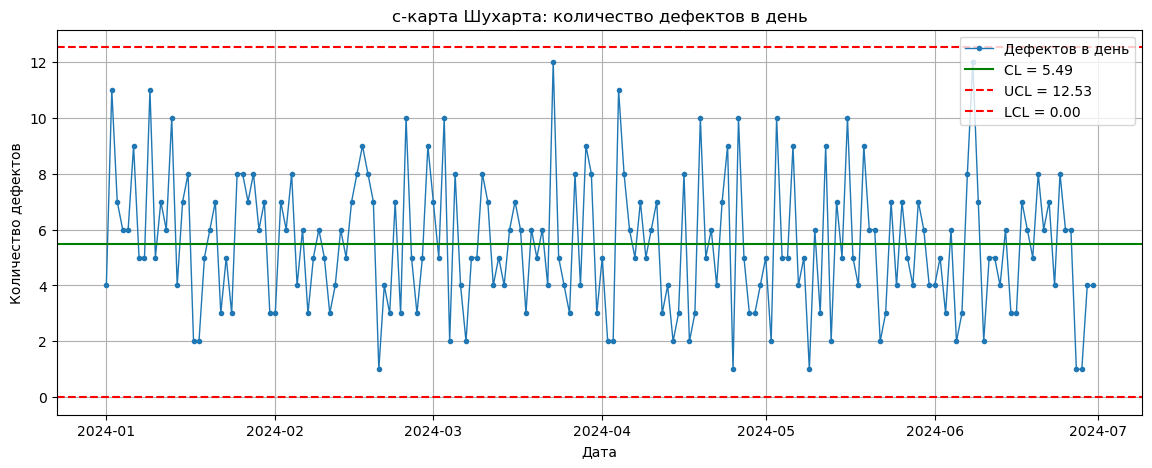

In [8]:
%matplotlib inline
# сама карта
plt.figure(figsize=(14, 5))
plt.plot(daily["d_defect"], daily["n_defects"], marker="o", markersize=3, linewidth=1, label="Дефектов в день")
plt.axhline(c_mean, color="green", label=f"CL = {c_mean:.2f}")
plt.axhline(ucl, color="red", linestyle="--", label=f"UCL = {ucl:.2f}")
plt.axhline(lcl, color="red", linestyle="--", label=f"LCL = {lcl:.2f}")
out = daily.filter(pl.col("out_of_control"))
plt.scatter(out["d_defect"], out["n_defects"], color="red", zorder=3)
plt.title("c-карта Шухарта: количество дефектов в день")
plt.xlabel("Дата")
plt.ylabel("Количество дефектов")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# правило Нельсона №2: 9 точек подряд по одну сторону от центральной линии
values = daily["n_defects"].to_list()
dates = daily["d_defect"].to_list()
run_len = 0
prev_side = 0
found = 0
for i in range(len(values)):
    if values[i] > c_mean:
        side = 1
    elif values[i] < c_mean:
        side = -1
    else:
        side = 0
    if side != 0 and side == prev_side:
        run_len += 1
    else:
        run_len = 1 if side != 0 else 0
    prev_side = side
    if run_len == 9:
        found += 1
        print("Серия из 9 точек", "выше" if side == 1 else "ниже", "CL, заканчивается", dates[i])
print("Найдено серий:", found)

Найдено серий: 0


Недель: 26
CL = 38.46, UCL = 57.07, LCL = 19.86
Недель за границами: 0


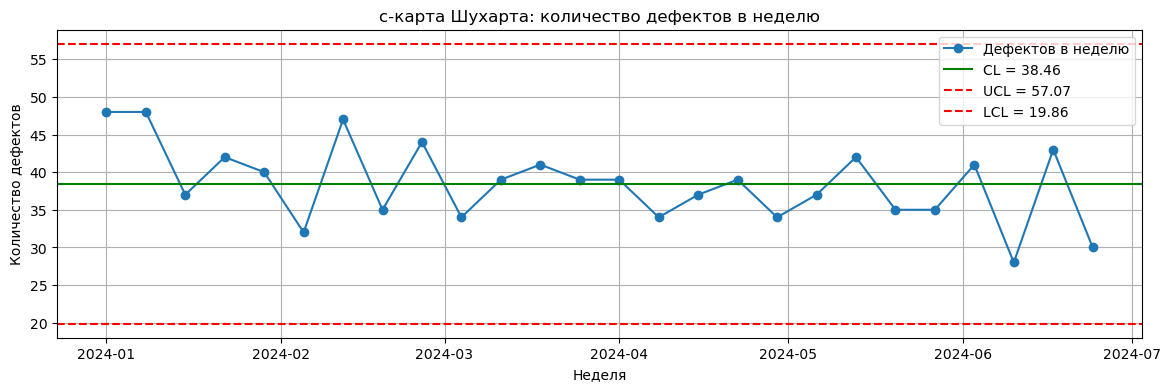

In [10]:
# то же самое по неделям: шума меньше, сдвиг уровня виден лучше
weekly = (
    daily.group_by(pl.col("d_defect").dt.truncate("1w").alias("week"))
    .agg(pl.col("n_defects").sum())
    .sort("week")
)
c_mean_w = weekly["n_defects"].mean()
ucl_w = c_mean_w + 3 * math.sqrt(c_mean_w)
lcl_w = max(0, c_mean_w - 3 * math.sqrt(c_mean_w))
print("Недель:", weekly.height)
print(f"CL = {c_mean_w:.2f}, UCL = {ucl_w:.2f}, LCL = {lcl_w:.2f}")
print("Недель за границами:", weekly.filter((pl.col("n_defects") > ucl_w) | (pl.col("n_defects") < lcl_w)).height)

plt.figure(figsize=(14, 4))
plt.plot(weekly["week"], weekly["n_defects"], marker="o", label="Дефектов в неделю")
plt.axhline(c_mean_w, color="green", label=f"CL = {c_mean_w:.2f}")
plt.axhline(ucl_w, color="red", linestyle="--", label=f"UCL = {ucl_w:.2f}")
plt.axhline(lcl_w, color="red", linestyle="--", label=f"LCL = {lcl_w:.2f}")
plt.title("c-карта Шухарта: количество дефектов в неделю")
plt.xlabel("Неделя")
plt.ylabel("Количество дефектов")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# среднее количество дефектов по дням недели (1 = понедельник)
(
    daily.with_columns(pl.col("d_defect").dt.weekday().alias("weekday"))
    .group_by("weekday")
    .agg(pl.col("n_defects").mean().alias("mean_defects"))
    .sort("weekday")
)

weekday,mean_defects
i8,f64
1,4.807692
2,5.730769
3,4.615385
4,4.846154
5,6.461538
6,6.076923
7,5.923077


In [12]:
# какие дефекты чаще и какие дороже
(
    df_def.group_by("defect_type", "severity")
    .agg(
        pl.len().alias("n"),
        pl.col("repair_cost").mean().round(2).alias("mean_cost"),
        pl.col("repair_cost").sum().round(2).alias("total_cost"),
    )
    .sort("total_cost", descending=True)
)

defect_type,severity,n,mean_cost,total_cost
str,str,u32,f64,f64
"""Structural""","""Minor""",139,530.49,73738.02
"""Functional""","""Critical""",114,547.79,62447.91
"""Cosmetic""","""Minor""",106,543.65,57626.72
"""Functional""","""Moderate""",112,505.85,56655.44
"""Structural""","""Critical""",112,498.5,55831.91
"""Functional""","""Minor""",113,467.28,52802.23
"""Cosmetic""","""Moderate""",96,531.2,50995.57
"""Cosmetic""","""Critical""",107,468.93,50175.43
"""Structural""","""Moderate""",101,468.85,47353.92


Вывод: в среднем 5.49 дефекта в день, дисперсия 5.74, почти как среднее, значит Пуассон подходит. За границу UCL = 12.53 ни одна точка не вышла, серий из 9 точек подряд тоже нет. По неделям тоже все в норме. Получается, процесс стабильный, резких скачков дефектов не было. С пятницы по воскресенье дефектов чуть больше, но не сильно. Больше всего денег ушло на Structural Minor, потому что их просто больше всего.